# 1. 회원정보 (회원 정보) EDA

카테고리 1 = **누구인가 / 회원 자격**. 정답 라벨 `Segment`(A~E)가 이 테이블에만 존재한다.

**분석 전제 (사전 검증 완료)**
- 조인키 정합성 clean: 모든 카테고리/월/train-test ID 일치, ID당 1행.
- `Segment`는 6개월간 **ID당 고정** (0% 변동) → 라벨은 ID당 1개.
- 극심한 클래스 불균형: E 80.1% / D 14.6% / C 5.3% / A 162명 / B 24명. 지표는 **Macro F1**.

여기서는 **201812 한 달 + 라벨 조인(이미 같은 테이블)** 기준으로, 각 피처가 A~E를 얼마나 가르는지 본다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

import glob, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd())=='eda' else os.getcwd()
MONTH = '201812'
SEG_ORDER = ['A','B','C','D','E']
SEG_COLORS = {'A':'#d1495b','B':'#edae49','C':'#66a182','D':'#2e4057','E':'#8d96a3'}
print('ROOT =', ROOT)

ROOT = C:\Users\82109\Desktop\DACON


## 1. 데이터 로드 (201812, train 회원정보)

In [2]:
f = glob.glob(os.path.join(ROOT, 'train', '1.*', f'{MONTH}_*.parquet'))[0]
df = pd.read_parquet(f)
print('shape:', df.shape)
df.head(3)

shape: (400000, 78)


,기준년월,ID,남녀구분코드,연령,Segment,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,소지카드수_이용가능_신용,입회일자_신용,입회경과개월수_신용,회원여부_연체,이용거절여부_카드론,동의여부_한도증액안내,수신거부여부_TM,수신거부여부_DM,수신거부여부_메일,수신거부여부_SMS,가입통신회사코드,탈회횟수_누적,최종탈회후경과월,탈회횟수_발급6개월이내,탈회횟수_발급1년이내,거주시도명,직장시도명,마케팅동의여부,유효카드수_신용체크,유효카드수_신용,유효카드수_신용_가족,유효카드수_체크,유효카드수_체크_가족,이용가능카드수_신용체크,이용가능카드수_신용,이용가능카드수_신용_가족,이용가능카드수_체크,이용가능카드수_체크_가족,이용카드수_신용체크,이용카드수_신용,이용카드수_신용_가족,이용카드수_체크,이용카드수_체크_가족,이용금액_R3M_신용체크,이용금액_R3M_신용,이용금액_R3M_신용_가족,이용금액_R3M_체크,이용금액_R3M_체크_가족,_1순위카드이용금액,_1순위카드이용건수,_1순위신용체크구분,_2순위카드이용금액,_2순위카드이용건수,_2순위신용체크구분,최종유효년월_신용_이용가능,최종유효년월_신용_이용,최종카드발급일자,보유여부_해외겸용_본인,이용가능여부_해외겸용_본인,이용여부_3M_해외겸용_본인,보유여부_해외겸용_신용_본인,이용가능여부_해외겸용_신용_본인,이용여부_3M_해외겸용_신용_본인,연회비발생카드수_B0M,연회비할인카드수_B0M,기본연회비_B0M,제휴연회비_B0M,할인금액_기본연회비_B0M,할인금액_제휴연회비_B0M,청구금액_기본연회비_B0M,청구금액_제휴연회비_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,카드신청건수,Life_Stage,최종카드발급경과월
0,201812,TRAIN_000000,2,40대,D,1,1,0,1,1,1,20130101,71,0,0,1,0,0,0,0,L사,1,66,0,0,서울,서울,1,2,1,0,1,0,2,1,0,1,0,1,1,0,0,0,-454,-454,0,0,0,3027,25,신용,0,0,체크,202105.0,202108.0,20160912.0,0,0,0,0,0,0,0개,0,0,0,0,0,0,0,0개,0개,0개,0개,0,자녀성장(2),27
1,201812,TRAIN_000001,1,30대,E,1,1,1,1,1,1,20170801,16,0,0,0,0,0,0,0,K사,1,103,0,0,경기,경기,1,1,1,0,0,0,1,1,0,0,0,1,1,0,0,0,7089,7089,0,0,0,7259,31,신용,0,0,NaN,202112.0,202202.0,20170122.0,0,0,0,0,0,0,0개,0,0,0,0,0,0,0,0개,0개,0개,0개,0,자녀성장(1),23
2,201812,TRAIN_000002,1,30대,C,1,1,0,1,1,1,20080401,128,0,0,1,0,0,0,0,S사,1,65,0,0,서울,서울,1,2,1,0,1,0,2,1,0,1,0,1,1,0,0,0,27336,27336,0,0,0,26968,52,신용,0,0,체크,202105.0,202112.0,20161113.0,1,1,0,0,0,0,0개,0,0,0,0,0,0,0,0개,0개,0개,0개,0,자녀출산기,25


## 2. 컬럼 개요 — dtype / 결측 / 카디널리티

78개 컬럼. 각 컬럼이 **쓸 수 있는지**(상수/고결측이면 버림) 판단한다.

In [3]:
meta = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'missing_%': (df.isna().mean()*100).round(2),
    'nunique': df.nunique(dropna=True),
})
meta = meta.sort_values(['nunique','missing_%'])
meta

,dtype,n_missing,missing_%,nunique
기준년월,int64,0,0.0,1
이용카드수_체크_가족,int64,0,0.0,1
이용금액_R3M_체크_가족,int64,0,0.0,1
연회비할인카드수_B0M,int64,0,0.0,1
할인금액_기본연회비_B0M,int64,0,0.0,1
...,...,...,...,...
_2순위카드이용금액,int64,0,0.0,34365
_1순위카드이용금액,int64,0,0.0,53417
이용금액_R3M_신용,int64,0,0.0,72442
이용금액_R3M_신용체크,int64,0,0.0,76821


### 2-1. 버릴 후보 — 상수 컬럼(정보 없음) & 고결측 컬럼

In [4]:
const_cols = meta.index[meta['nunique'] <= 1].tolist()
high_missing = meta.index[meta['missing_%'] >= 40].tolist()
print(f'상수 컬럼 ({len(const_cols)}개) — 분산 0, 정보 없음:')
for c in const_cols: print('   -', c)
print(f'\n고결측 컬럼 (>=40% 결측, {len(high_missing)}개):')
print(meta.loc[high_missing, ['missing_%','nunique']])

상수 컬럼 (10개) — 분산 0, 정보 없음:
   - 기준년월
   - 이용카드수_체크_가족
   - 이용금액_R3M_체크_가족
   - 연회비할인카드수_B0M
   - 할인금액_기본연회비_B0M
   - 할인금액_제휴연회비_B0M
   - 상품관련면제카드수_B0M
   - 임직원면제카드수_B0M
   - 우수회원면제카드수_B0M
   - 기타면제카드수_B0M

고결측 컬럼 (>=40% 결측, 1개):
            missing_%  nunique
_2순위신용체크구분      40.43        2


## 3. 타깃 Segment 분포 (불균형 재확인)

          count  ratio_%
Segment                 
A           162    0.040
B            24    0.006
C         21265    5.316
D         58207   14.552
E        320342   80.086


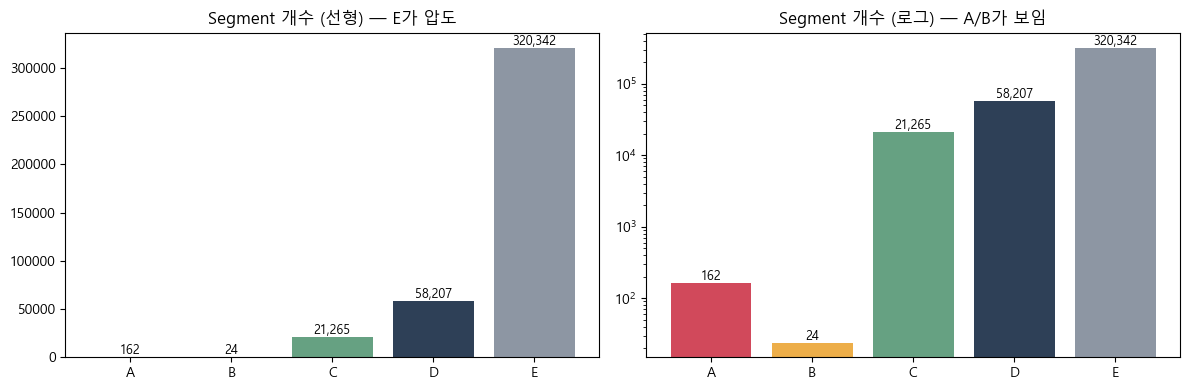

In [5]:
vc = df['Segment'].value_counts().reindex(SEG_ORDER)
ratio = (vc/len(df)*100).round(3)
summary = pd.DataFrame({'count': vc, 'ratio_%': ratio})
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(SEG_ORDER, vc.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[0].set_title('Segment 개수 (선형) — E가 압도')
for i,v in enumerate(vc.values): ax[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
ax[1].bar(SEG_ORDER, vc.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[1].set_yscale('log'); ax[1].set_title('Segment 개수 (로그) — A/B가 보임')
for i,v in enumerate(vc.values): ax[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## 4. 세그먼트별 수치형 피처 비교

핵심 질문: **어떤 피처가 A~E를 가르는가.** 평균은 E에 지배되므로 **세그먼트별 그룹 통계(중앙값)** 로 본다.
분리도가 큰(=세그먼트 간 중앙값 차이가 큰) 피처를 상위로 랭킹한다.

In [6]:
# 분석 대상 수치형 = int/float 중 상수 제외, 식별자/라벨 제외
drop = set(const_cols) | {'기준년월'}
num_cols = [c for c in df.columns
            if c not in drop and c not in ('ID','Segment')
            and pd.api.types.is_numeric_dtype(df[c])]
print(f'수치형 분석 대상: {len(num_cols)}개')

# 세그먼트별 중앙값 테이블
med = df.groupby('Segment')[num_cols].median().reindex(SEG_ORDER).T

# 분리도 점수: 세그먼트 중앙값들의 (max-min) / (전체 IQR+eps) 로 스케일 보정
iqr = (df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)).replace(0, np.nan)
sep = ((med.max(axis=1) - med.min(axis=1)) / (iqr + 1e-9)).sort_values(ascending=False)
med_sorted = med.loc[sep.index]
med_sorted.insert(0, 'sep_score', sep.round(2))
print('세그먼트별 중앙값 — 분리도 높은 상위 25개')
med_sorted.head(25)

수치형 분석 대상: 58개


세그먼트별 중앙값 — 분리도 높은 상위 25개


Segment,sep_score,A,B,C,D,E
이용금액_R3M_신용,5.55,109321.5,93539.0,51273.0,27177.0,4903.0
_1순위카드이용금액,5.12,81348.5,77988.5,34290.0,19377.0,3913.0
이용금액_R3M_신용체크,5.07,110342.0,99105.5,59870.0,32749.0,5661.0
_2순위카드이용금액,4.11,14027.0,5290.0,7684.0,3471.0,0.0
_2순위카드이용건수,2.59,41.5,10.5,29.0,16.0,0.0
_1순위카드이용건수,2.42,141.5,147.0,81.0,61.0,9.0
입회일자_신용,2.20,19995651.0,20081001.0,20090201.0,20120701.0,20150501.0
입회경과개월수_신용,2.12,227.5,122.0,118.0,77.0,43.0
이용카드수_신용,2.00,3.0,2.0,2.0,2.0,1.0
이용가능카드수_신용,2.00,3.0,2.0,2.0,2.0,1.0


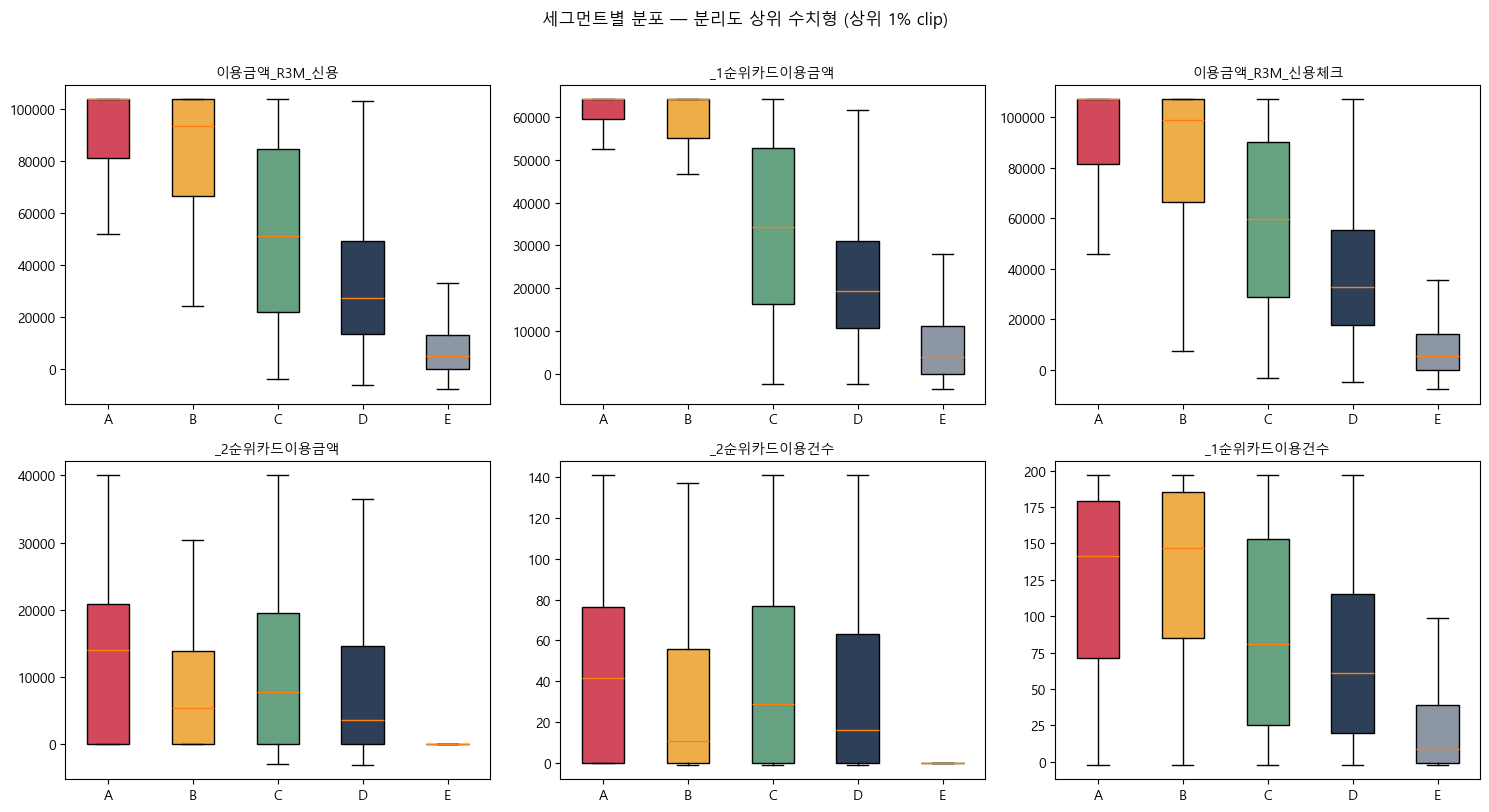

In [7]:
# 상위 분리 피처 6개 박스플롯 (극단치 제거해 형태만)
top_feats = sep.index[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, feat in zip(axes.ravel(), top_feats):
    data = [df.loc[df['Segment']==s, feat].clip(upper=df[feat].quantile(0.99)) for s in SEG_ORDER]
    bp = ax.boxplot(data, labels=SEG_ORDER, showfliers=False, patch_artist=True)
    for patch, s in zip(bp['boxes'], SEG_ORDER): patch.set_facecolor(SEG_COLORS[s])
    ax.set_title(feat, fontsize=10)
plt.suptitle('세그먼트별 분포 — 분리도 상위 수치형 (상위 1% clip)', y=1.01)
plt.tight_layout(); plt.show()

## 5. 저카디널리티 / 범주형 피처 vs Segment

연령·성별·Life_Stage·거주지 등. 각 범주 안에서 **세그먼트 구성비**가 전체와 다르면 신호.

In [8]:
cat_cols = ['연령', '남녀구분코드', 'Life_Stage', '거주시도명',
            '소지카드수_유효_신용', '유효카드수_신용', '카드신청건수']
cat_cols = [c for c in cat_cols if c in df.columns]

for c in cat_cols:
    ct = pd.crosstab(df[c], df['Segment']).reindex(columns=SEG_ORDER, fill_value=0)
    row_pct = (ct.div(ct.sum(axis=1), axis=0)*100).round(2)
    print(f'\n=== {c} : 값별 세그먼트 구성비(%) (n=행합) ===')
    out = row_pct.copy(); out['n'] = ct.sum(axis=1)
    print(out.to_string())


=== 연령 : 값별 세그먼트 구성비(%) (n=행합) ===
Segment     A     B     C      D      E       n
연령                                             
20대      0.00  0.00  2.15  13.54  84.30   31980
30대      0.01  0.01  5.45  17.27  77.26   98691
40대      0.05  0.01  6.60  15.79  77.55  122191
50대      0.07  0.01  5.43  12.96  81.53   91057
60대      0.04  0.00  4.00  10.81  85.14   41165
70대이상    0.05  0.00  3.62   8.57  87.76   14916

=== 남녀구분코드 : 값별 세그먼트 구성비(%) (n=행합) ===
Segment     A     B     C      D      E       n
남녀구분코드                                         
1        0.05  0.01  6.25  15.79  77.90  209218
2        0.02  0.01  4.29  13.19  82.48  190782

=== Life_Stage : 값별 세그먼트 구성비(%) (n=행합) ===
Segment        A     B     C      D      E       n
Life_Stage                                        
가족구축기       0.00  0.00  4.00  17.14  78.85   40366
노년생활        0.03  0.00  3.38   9.41  87.18   38828
독신          0.01  0.01  1.59  11.25  87.14   15399
자녀독립기       0.05  0.00  4.33  11.07  84.56   3316


=== 거주시도명 : 값별 세그먼트 구성비(%) (n=행합) ===
Segment     A     B     C      D      E       n
거주시도명                                          
강원       0.07  0.00  3.01  15.51  81.42    1464
경기       0.06  0.00  6.70  15.95  77.28  108801
경남       0.02  0.01  3.69  13.36  82.92   16601
경북       0.01  0.01  3.83  11.37  84.78   14185
광주       0.06  0.00  4.57  12.55  82.82    5290
대구       0.01  0.00  4.11  12.85  83.03   14453
대전       0.02  0.00  4.69  13.04  82.25   23008
부산       0.02  0.01  3.94  11.41  84.61   24847
서울       0.04  0.01  5.63  15.45  78.86  117352
세종       0.00  0.00  7.81  15.62  76.56      64
울산       0.06  0.01  4.98  14.80  80.15   13243
인천       0.03  0.00  4.54  13.52  81.91   25633
전남       0.02  0.00  3.71  12.68  83.59    9119
전북       0.10  0.00  4.90  16.55  78.46    2061
제주       0.00  0.00  6.27  18.21  75.52     670
충남       0.04  0.00  4.33  14.55  81.08    4688
충북       0.02  0.01  4.13  13.83  82.00   18521

=== 소지카드수_유효_신용 : 값별 세그먼트 구성비(%) (n=행합) ===
Segm


=== 카드신청건수 : 값별 세그먼트 구성비(%) (n=행합) ===
Segment     A     B     C      D     E       n
카드신청건수                                        
0        0.04  0.01  5.30  14.55  80.1  389034
1        0.05  0.01  5.91  14.64  79.4   10966


## 6. 소수클래스 A / B 집중 탐색

A(162) · B(24)는 Macro F1의 승부처. **A/B에서 유별나게 튀는 피처**를 찾는다.
각 수치형에 대해 (A중앙값, B중앙값) vs (전체중앙값)의 배율을 본다.

In [9]:
glob_med = df[num_cols].median()
a_med = df[df['Segment']=='A'][num_cols].median()
b_med = df[df['Segment']=='B'][num_cols].median()

def ratio(x, base): return (x / base.replace(0, np.nan))

cmp = pd.DataFrame({
    'A_median': a_med, 'B_median': b_med, 'ALL_median': glob_med,
    'A/ALL': ratio(a_med, glob_med).round(2),
    'B/ALL': ratio(b_med, glob_med).round(2),
})
# A 또는 B가 전체 대비 크게 벗어난 것
cmp['max_dev'] = cmp[['A/ALL','B/ALL']].apply(lambda r: max(abs(np.log(r+1e-9))), axis=1)
print('A/B가 전체 중앙값 대비 가장 크게 다른 피처 상위 20')
cmp.sort_values('max_dev', ascending=False).drop(columns='max_dev').head(20)

A/B가 전체 중앙값 대비 가장 크게 다른 피처 상위 20


,A_median,B_median,ALL_median,A/ALL,B/ALL
회원여부_이용가능_카드론,1.0,0.0,1.0,1.00,0.00
이용금액_R3M_신용,109321.5,93539.0,7623.0,14.34,12.27
_1순위카드이용금액,81348.5,77988.5,6077.0,13.39,12.83
이용금액_R3M_신용체크,110342.0,99105.5,8718.0,12.66,11.37
_1순위카드이용건수,141.5,147.0,15.0,9.43,9.80
입회경과개월수_신용,227.5,122.0,53.0,4.29,2.30
이용카드수_신용,3.0,2.0,1.0,3.00,2.00
이용카드수_신용체크,3.0,2.5,1.0,3.00,2.50
유효카드수_신용,3.0,2.0,1.0,3.00,2.00
이용가능카드수_신용,3.0,2.0,1.0,3.00,2.00


In [10]:
# 연령/Life_Stage 상에서 A,B 비중 (희귀하므로 개수로)
for c in ['연령', 'Life_Stage', '거주시도명']:
    if c not in df.columns: continue
    ab = df[df['Segment'].isin(['A','B'])].groupby([c,'Segment']).size().unstack(fill_value=0)
    ab = ab.reindex(columns=['A','B'], fill_value=0)
    ab['A+B'] = ab.sum(axis=1)
    print(f'\n=== {c} : A/B 개수 분포 ===')
    print(ab.sort_values('A+B', ascending=False).to_string())


=== 연령 : A/B 개수 분포 ===
Segment   A  B  A+B
연령                 
50대      63  8   71
40대      60  8   68
30대      13  7   20
60대      18  0   18
70대이상     7  0    7
20대       1  1    2

=== Life_Stage : A/B 개수 분포 ===
Segment      A   B  A+B
Life_Stage             
자녀성장(2)     72   7   79
자녀성장(1)     52  12   64
자녀독립기       15   1   16
노년생활        12   0   12
자녀출산기        9   2   11
가족구축기        1   1    2
독신           1   1    2

=== 거주시도명 : A/B 개수 분포 ===
Segment   A   B  A+B
거주시도명               
경기       67   3   70
서울       50  12   62
부산        6   3    9
울산        8   1    9
인천        7   0    7
충북        4   2    6
경남        3   2    5
대전        4   0    4
경북        2   1    3
광주        3   0    3
전남        2   0    2
전북        2   0    2
충남        2   0    2
강원        1   0    1
대구        1   0    1


## 7. 요약 & 발견

### 핵심 발견 — **Segment는 사실상 "이용/가치 등급(A=상위 ... E=하위)"의 순서형 라벨**
`이용금액_R3M_신용`(최근3개월 신용 이용금액) 중앙값이 **A 109,321 → B 93,539 → C 51,273 → D 27,177 → E 4,903** 으로 A→E 단조 감소.
카드 이용금액·이용건수·보유카드수·가입기간(입회경과개월수)이 모두 같은 방향(A 상위, E 하위)으로 정렬된다.
→ **E = 사실상 휴면/저이용 고객, A = 고이용 우량 고객.** 즉 세그먼트는 명목형이 아니라 **순서형(tier)** 에 가깝다.
→ 모델링 시사점: (1) 소비 관련 피처(카테고리 3 승인매출)가 지배적일 것, (2) 순서형 구조를 활용(ordinal) 가능.

### 버릴 컬럼
- **상수 컬럼 10개** (`기준년월` 포함, 면제카드수/할인금액 계열): 분산 0 → 제거.
- **고결측 1개**: `_2순위신용체크구분`(40.4%). 그 외 `가입통신회사코드`(15.6%)·`직장시도명`(10.4%)·`최종유효년월`·`최종카드발급일자`는 중간 결측 → 결측 자체가 신호일 수 있어 플래그 처리 고려.

### Segment를 잘 가르는 수치형 (분리도 상위)
`이용금액_R3M_신용/신용체크`, `_1·2순위카드이용금액·건수`, `입회일자·입회경과개월수_신용`, `이용/유효/이용가능 카드수_신용`. 
→ 전부 **이용 규모 + 관계 깊이(가입기간·보유카드수)**.

### 범주형 신호
- `연령`·`Life_Stage`: A/B(우량)는 **40~50대 · 자녀성장기**에 집중. E는 젊은 층·독신 비중이 상대적으로 큼.
- `거주시도명`: A/B는 경기·서울에 집중(수도권).
- 단, A(162)·B(24)는 절대수가 적어 범주형은 과적합 주의.

### 소수클래스 A / B
- A와 B는 수치 프로필이 서로 **매우 유사**(둘 다 최상위 이용). B는 `_2순위카드이용금액`이 A보다 크게 낮은 등 미세 차이만 존재 → **A vs B 분리는 회원정보만으로는 어렵다.** 다른 카테고리(승인매출·잔액) 신호가 필요.
- B는 24명뿐 → 어떤 피처로도 통계적 안정성 확보 곤란. few-shot 취급.

